#### test data 
>4.1 Data
- n = 100 
- y_i = 0.25 sin(pi x_i ) + epslon_i
- x_i = U(o,1)
- epslon_i = (1 - theta) N(0,sigma^2) + theta*n(o, 25sigam^2)
- sigma = 0.5
- theta = 0.1
- P(x) = 0.3 + 0.5 sin^2(5(x + 0.2))


In [5]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
np.random.seed(42) 
n = 100
sigma = 0.5
eta = 0.1

x = np.random.uniform(0,1,n)

clean_noise = np.random.normal(0,sigma,n)
contaminated_noise = np.random.normal(0,0.25*sigma,n)
epsilon = (1-eta)*clean_noise + eta*contaminated_noise

y_true = 0.25 * np.pi * np.sin(np.pi * x)
y = y_true + epsilon

In [7]:
y

array([ 0.764512  ,  0.00473812,  0.6238549 , -0.11242963,  0.27869908,
        0.51966426,  0.79418772,  0.09336481,  0.37948789,  0.40662405,
        0.46860123,  0.22116158,  0.14562379,  0.69795819,  0.46273585,
        0.87450101,  0.32824866,  0.62000427,  0.59323191, -0.03132478,
        0.85961077,  0.4526723 ,  0.62684417,  0.59733934,  0.14548587,
        0.30844493,  0.32031064,  0.43676074,  0.66272963,  0.28430553,
        1.59621764,  0.48589512,  0.28172919,  0.14023704, -0.77167602,
        0.44698756,  0.68105346,  1.35383357,  0.56697535,  0.91674044,
        0.26851376,  0.25644266,  0.59288854,  0.56012215,  0.95536335,
        0.25266472,  1.29178693,  0.13284588,  1.03514349,  1.43021823,
       -0.37000507,  0.24152027,  0.18428499,  0.03673806,  0.04161485,
        0.22439709, -0.26192228,  0.65856161, -0.27572285,  1.375482  ,
        0.36007586,  0.4487348 ,  0.76028873,  0.16396822,  0.69907732,
        1.3651234 , -0.38058686,  0.55115613,  0.28421282,  0.37

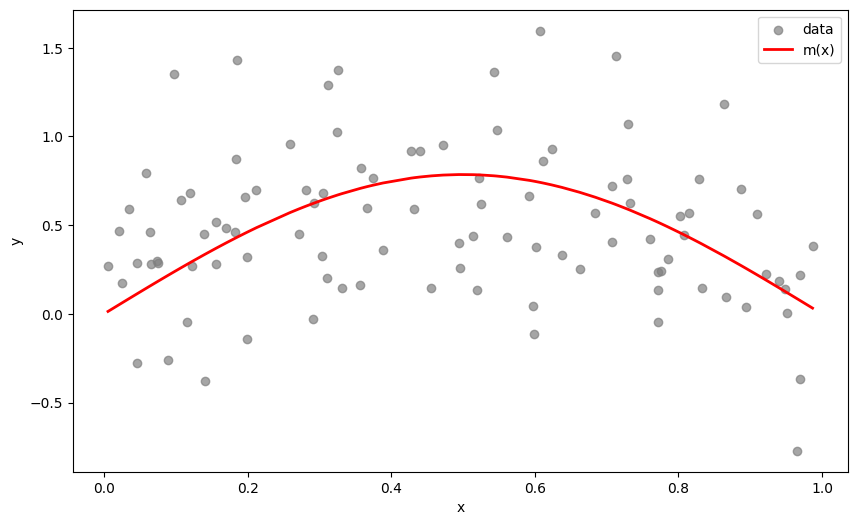

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(x, y, label = 'data', alpha = 0.7,color = 'gray')
plt.plot(np.sort(x),0.25 * np.pi * np.sin(np.pi * np.sort(x)), 'r-',label= 'm(x)' , linewidth = 2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [9]:
p_x = 0.3 + 0.5 * np.sin(5 * (x + 0.2))**2
p_x

array([0.33528854, 0.42761355, 0.79862737, 0.58305374, 0.77841536,
       0.77843987, 0.76171325, 0.63191194, 0.58913056, 0.78534889,
       0.69830416, 0.38827271, 0.70547133, 0.68888201, 0.7449176 ,
       0.74242066, 0.46898133, 0.40751819, 0.30016437, 0.50035658,
       0.61536809, 0.7920198 , 0.4981155 , 0.34646749, 0.30956516,
       0.77755497, 0.71402724, 0.38673137, 0.56752662, 0.74485003,
       0.60491523, 0.76132785, 0.7704564 , 0.43162041, 0.39657349,
       0.7476213 , 0.4681032 , 0.79660986, 0.75877969, 0.30174849,
       0.79922442, 0.35382492, 0.72458736, 0.52563132, 0.58106677,
       0.72425644, 0.45155924, 0.39804717, 0.45567506, 0.7400863 ,
       0.38889358, 0.78678864, 0.45278011, 0.56182079, 0.58117319,
       0.49466994, 0.79181032, 0.72087748, 0.74291971, 0.42127   ,
       0.31938697, 0.54972467, 0.71261676, 0.3613336 , 0.52579893,
       0.44645976, 0.79109879, 0.75672949, 0.78064451, 0.35838762,
       0.78900563, 0.7158273 , 0.66642486, 0.73632089, 0.78430

In [10]:
delta = np.random.rand(n) < p_x
print(f"percentage of existing values: {np.mean(delta):.1%}")

percentage of existing values: 49.0%


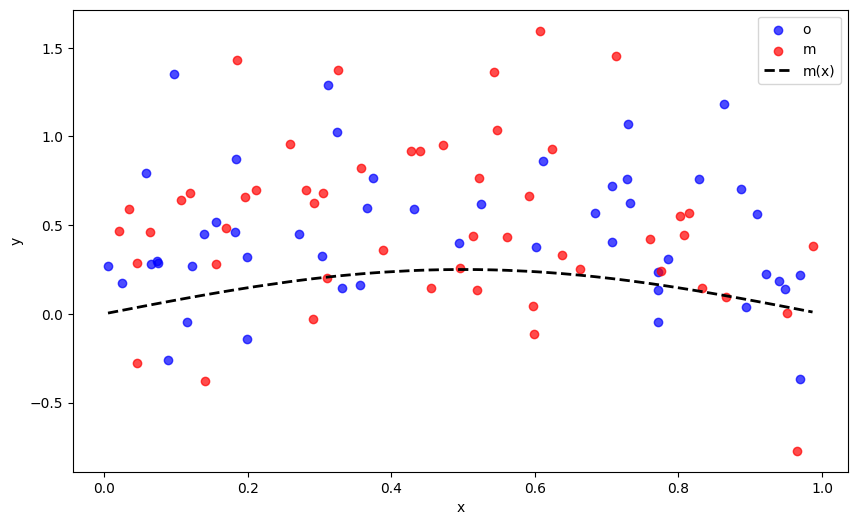

In [11]:
plt.figure(figsize = (10,6))
plt.scatter(x[delta==1],y[delta==1],label='o',color='blue',alpha=0.7)
plt.scatter(x[delta==0],y[delta==0],label='m',color='red',alpha=0.7)
plt.plot(np.sort(x),0.25 * np.sin(np.pi * np.sort(x)), 'k--' ,label ='m(x)',linewidth = 2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


In [12]:
def gussian_kernel(u):
    return np.exp(-0.5 * u**2)

In [14]:
x0 = 0.5
h = 0.3
numerator = gussian_kernel((x - x0) / h) * delta
denominator = np.sum(numerator)
if denominator == 0:
    weights = np.zeros_like(x)
else :
    weights = numerator / denominator

In [18]:
np.sum(weights)

np.float64(0.9999999999999998)